# CNN (Convolutional Neural-Networ)
### Author: Krzysztof Chmielewski

### Sizes & parameters of convolutional layers

For given sizes of convolution layer with:
- Input size: $W$
- Filter (Kernel) size: $K$
- Padding: $P$
- Stride: $S$ (how many steps Kernel advances each time)

Output size will be: $\frac{W - K + 2P}{S} + 1$

---

**Example**:
- Input volume: 3x32x32
- 10 filters of size 6x6 with stride 1
- Padding of 2

This gives us $W = 32$, $K = 6$, $P = 2$, $S = 1$, thus output size will be $31$ and output volume will be 10x31x31, because we have 10 filters

### Pooling layers
Pooling is a way of downsizing dimension by sliding pooling kernel and extracting given value from that area.

The most common would be:
- **Max Pooling** - extract max value from a given area
- **Average Pooling** - compute average value of all values from given area
---
**Example**

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2022/03/9217311042_2019_8345_Fig4_HTML.webp" width="400" height="300">

### Regularization methods 
- Dropout layers - turning off random number of neurons during model learning
- Weigth regularization - 
- Early stopping - stopping the learning process when results are not changing that much
- Batch normalization - 

# Coding CNN

### Imports
We import libraries that enable us to create our neural network:
- `torch` - Main PyTorch library that provides tensors (GPU-enabled object with autograd that makes learning NN possible)
- `torch.nn` - Neural Network module containing layer builders like `Conv2d`, `Linear`, `ReLU`, etc.
- `torch.optim` - Optimization algorithms like Adam, SGD, etc.
- `torchvision` - Computer vision utilities that contains datasets like CIFAR-10 on which we will build example CNN
- `torchvision.transforms` - Image preprocessing tools like normalization, resizing, etc.
- `matplotlib.pyplot` - Used for visualizing images

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# We check availability and select the device which will be used - GPU or CPU
# Deep Learning is much faster on GPU so we want to use cuda (GPU) rather than CPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cuda


### Dataset selection and preprocessing
Now we prepare transformations for images from dataset. Compose will apply multiple preprocessing steps sequentially:
- `.ToTensor()` - this will convert image (0-255) to torch.FloatTensor (0-1) and change shape from (H,W,C) to (C,H,W), because CNNs expect channels first
- `.Normalize()` - this normalizes data to unit gaussian ($x_{norm} = \frac{x-mean}{std}$). We give three values because CIFAR images have three channels: RGB

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5), # mean
        (0.5, 0.5, 0.5)  # std
    )])

Now let's download CIFAR-10 dataset which is available in `torchvision.datasets`.

This:
- Downloads CIFAR-10
- Applies transform to each image
- `train=True` means 50,000 training images

Then in `trainloader`:
- Splits dataset into batches
- Batch size = 64 images per step
- `shuffle=True` randomizes order each epoch

In [5]:
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True
)

100.0%
/home/krzysztof/PROJECTS/ai_notebooks/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Same logic for test set (no need to shuffle).

In [8]:
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False
)

/home/krzysztof/PROJECTS/ai_notebooks/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Building CNN

Our SimpleCNN is a function:
$$ f(image) \rarr class \ scores $$

It:
- Extracts spatial features
- Compresses them
- Classifies image

It learns:
- Early layers - edges
- Middle layers - shapes
- Final layers - object identity

This CNN looks like this

<img src="./simple_CNN.png" width=600 height=450>

In [34]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First convolutional layer:
        # Input: (3,32,32) - 3 (input channels RGB), 32 (number of filters)
        # Output: (32,32,32)
        # Second convolutional layer (32 x 64)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Pooling layer using max pooling
        # Kernel: 2
        # Stride: 2
        # This reduces spatial size from 32x32 to 16x16 to 8x8 (because we will pool twice)
        self.pool = nn.MaxPool2d(2,2)

        # First fully connected layer
        # Channels: 64
        # Input after pooling: 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 512)

        # Second fully connected layer (accordingly to CIFAR-10 dataset)
        # Features: 512
        # Classes: 10
        self.fc2 = nn.Linear(512, 10)

        # Non-linear activation layer 
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x)) # outputs (batch, 32,32,32)
        x = self.pool(x)             # outputs (batch, 32,16,16)

        x = self.relu(self.conv2(x)) # outputs (batch, 64,16,16)
        x = self.pool(x)             # outputs (batch, 64,8,8)

        x = x.view(-1, 64 * 8 * 8)   # -1 automatically infers batch size -> transforms (batch, 64,8,8) to (batch, 4096)

        x = self.relu(self.fc1(x))   # outputs (batch, 512)
        x = self.fc2(x)              # outputs (batch, 10)

        return x                     # returns raw scores (logits)

Now we create model object and move it to device. Criterion (here as `CrossEntropyLoss`) is a loss function that applies softmax and computes negative log likelihood. Optimizer (here as `Adam`) will update weights using gradient.

In [35]:
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # learning rate - first hyperparameter

### Training

In [37]:
epoch_num = 5 # second hyperparameter

for epoch in range(epoch_num):

    # running loss for information display after every epoch
    running_loss = 0.0

    # trainloader will give us batches of images and labels for them
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        # clear previous gradients, because PyTorch accumulates them by default
        optimizer.zero_grad()

        # forward pass - get raw scores from CNN for given images
        outputs = model(images)

        # compute loss - softmax & negative log likelihood on logits
        loss = criterion(outputs, labels)

        # backpropagation - compute gradients
        loss.backward()

        # update weights with those gradients
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1, Loss: 1.6770
Epoch 2, Loss: 1.2696
Epoch 3, Loss: 1.0787
Epoch 4, Loss: 0.9110
Epoch 5, Loss: 0.7509


### Evaluation

In [38]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 79.06


### Results visualization

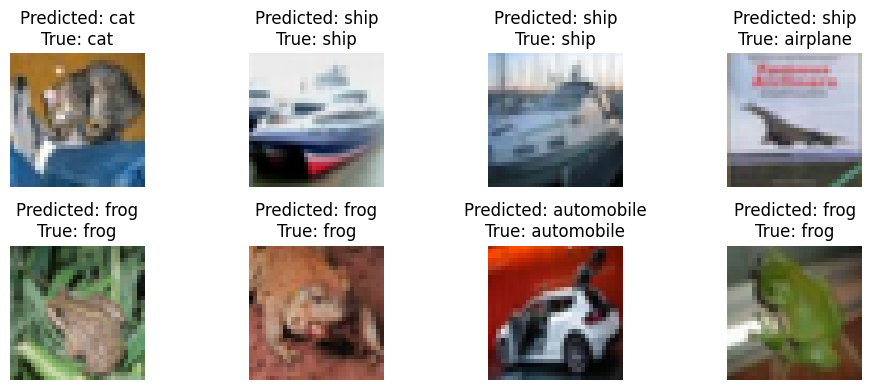

In [ ]:
model.eval()

images, labels = next(iter(testloader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Move to CPU for plotting
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

fig = plt.figure(figsize=(10, 4))
classes = trainset.classes

for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(f"Predicted: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()